# Observability, Monitoring & Alerting — Tools

Tools organized by category, followed by popular stack combinations.

---

## Categories
1. [Instrumentation & Collection](#1)
2. [Metrics Storage & Query](#2)
3. [Log Management](#3)
4. [Distributed Tracing](#4)
5. [Visualization & Dashboards](#5)
6. [Alerting & On-Call](#6)
7. [All-in-One Commercial Platforms](#7)
8. [Stack Combinations](#8)
   - TIG — Telegraf + InfluxDB + Grafana
   - PLG — Prometheus + Loki + Grafana
   - ELK — Elasticsearch + Logstash + Kibana
   - EFK — Elasticsearch + Fluentd + Kibana
   - OTel + Grafana Stack
   - Datadog (Full-Stack Commercial)


## 1. Instrumentation & Collection

<a name="1"></a>

> These tools sit closest to your application. They **collect raw signals** (metrics, logs, traces) and ship them to a storage backend.

---

### Telegraf
- **What:** Agent that collects metrics from the host, apps, and 300+ plugins (CPU, Kafka, MySQL, Docker, etc.)
- **Why:** Push-based. Runs on the VM alongside your app, pulls stats, converts to InfluxDB Line Protocol, and forwards to InfluxDB or any other output.
- **Key trait:** Plugin-based — one binary handles collection from almost any source.
- **Used in:** TIG stack

```
Application → Telegraf (collect + transform) → InfluxDB / Prometheus / Datadog
```

---

### Prometheus Exporters
- **What:** Small sidecar processes that expose metrics from third-party software in Prometheus format (`/metrics` HTTP endpoint).
- **Why:** Prometheus can't instrument software it doesn't own. Exporters bridge the gap.
- **Examples:** `node_exporter` (OS metrics), `postgres_exporter`, `redis_exporter`, `blackbox_exporter` (probes URLs).

```
MySQL ← mysql_exporter (scrapes internals) → exposes /metrics → Prometheus scrapes
```

---

### OpenTelemetry SDK / Collector
- **What:** Vendor-neutral CNCF standard for instrumenting code and collecting traces, metrics, and logs.
- **Why:** Write instrumentation once, export to any backend (Jaeger, Prometheus, Datadog, Grafana). Prevents vendor lock-in.
- **Two parts:**
  - **SDK** — in-process library you add to your code
  - **Collector** — standalone service that receives, processes (batching, sampling, PII scrubbing), and exports to backends
- **Used in:** OTel + Grafana stack, any vendor-neutral setup

```
App (OTel SDK) → OTLP → OTel Collector → [Tempo, Prometheus, Loki, Datadog, ...]
```

---

### Fluentd / Fluent Bit
- **What:** Log shippers that tail log files or receive log streams and forward to storage.
- **Why:** Decouple log production from log storage. Apps write to stdout/files; Fluentd routes and transforms.
- **Difference:** Fluent Bit is lightweight (C, ~1MB RAM) for edge/containers. Fluentd is heavier but more feature-rich.
- **Used in:** EFK stack (Elasticsearch + Fluentd + Kibana)

```
App logs (stdout) → Fluent Bit (tail + parse) → Elasticsearch / Loki / Splunk
```

---

### Logstash
- **What:** Data processing pipeline — ingest logs from many sources, transform/filter, and output to Elasticsearch.
- **Why:** Powerful transformation (grok parsing, geo-IP enrichment, field manipulation).
- **Downside:** Heavy (JVM). Often replaced by Fluent Bit + Beats for lower overhead.
- **Used in:** ELK stack

---

### Beats (Filebeat, Metricbeat)
- **What:** Lightweight Elastic shippers. Filebeat tails log files; Metricbeat collects system metrics.
- **Why:** Low-overhead agent that feeds data into Logstash or Elasticsearch directly.
- **Used in:** ELK stack as the lightweight collection layer


## 2. Metrics Storage & Query

<a name="2"></a>

> These are **time-series databases (TSDB)** — purpose-built to store and query numeric data over time. Regular relational DBs are too slow for this workload.

---

### Prometheus
- **What:** Pull-based metrics TSDB. Scrapes `/metrics` endpoints on a configurable interval and stores time-series data locally.
- **Why:** De-facto standard in cloud-native (Kubernetes-native). Powerful PromQL query language. Huge exporter ecosystem.
- **Limitation:** No long-term storage — local disk only. Use Thanos or Cortex for multi-week/month retention.
- **Model:** Pull (Prometheus scrapes targets) — opposite of push-based tools like Telegraf.

```
Prometheus scrapes:
  → app:8080/metrics  every 15s
  → node_exporter:9100/metrics  every 15s
  → postgres_exporter:9187/metrics  every 30s
```

---

### InfluxDB
- **What:** Push-based time-series database. Apps/agents write metrics to it using the **Line Protocol** over HTTP.
- **Why:** Optimised for high write throughput. Works well with Telegraf (same company — InfluxData). Good for IoT/infrastructure metrics.
- **Line Protocol format:**
```
measurement,tag_key=tag_val field_key=field_val timestamp
cpu,host=server01 usage=64.3 1609459200000000000
```
- **Used in:** TIG stack

---

### Thanos
- **What:** Highly available, long-term storage layer on top of Prometheus.
- **Why:** Prometheus alone can't survive node failures or retain data beyond a few weeks cost-effectively. Thanos adds global querying across multiple Prometheus instances and offloads old data to object storage (S3, GCS).
- **Used when:** You have multiple Prometheus instances (multi-cluster) and need unified dashboards + years of retention.

---

### Cortex / Mimir
- **What:** Horizontally scalable, multi-tenant Prometheus backend.
- **Why:** Thanos is simpler but Cortex/Mimir handles higher write throughput and stricter multi-tenancy. Grafana Mimir is the actively developed successor to Cortex.
- **Used when:** Large-scale SaaS with thousands of tenants each needing isolated metrics.

---

### VictoriaMetrics
- **What:** High-performance drop-in replacement for Prometheus + Thanos.
- **Why:** Significantly lower memory usage and faster queries than Prometheus at scale. Supports PromQL. Single binary makes ops simple.
- **Used when:** Prometheus is too resource-heavy at your scale and you want simplicity over the Thanos/Cortex complexity.


## 3. Log Management

<a name="3"></a>

> Tools for **storing, indexing, searching, and retaining log data** at scale.

---

### Elasticsearch
- **What:** Distributed full-text search and analytics engine built on Apache Lucene.
- **Why:** Can index and search massive volumes of unstructured/structured log data in near-real-time. Powers the ELK/EFK stack.
- **Key capability:** Full-text search, regex, aggregations, geo queries.
- **Downside:** Expensive to operate (high memory + disk). Operationally complex at scale.

---

### Kibana
- **What:** Visualization and exploration UI for Elasticsearch.
- **Why:** Provides log search (Discover), dashboards, and alerting on top of Elasticsearch. The "K" in ELK.
- **Used for:** Ad-hoc log exploration, building operational dashboards over log data.

---

### Grafana Loki
- **What:** Log aggregation system designed to be **cheap and simple** — indexes only labels, not the full log content.
- **Why:** 10–100x cheaper to run than Elasticsearch because it doesn't full-text index logs. Queries logs using LogQL (similar to PromQL). Native Grafana integration — same tool for metrics and logs.
- **Tradeoff:** Slower full-text search than Elasticsearch. Suited for operational logs queried by known labels (service, level, trace_id).
- **Used in:** PLG / OTel + Grafana stack

```
LogQL example:
{service="checkout", level="error"} |= "timeout" | json | duration > 2s
```

---

### Splunk
- **What:** Enterprise platform for log ingestion, search, and SIEM (Security Information and Event Management).
- **Why:** Extremely powerful search and correlation. Widely used in large enterprises and security teams.
- **Downside:** Very expensive (volume-based pricing). Overkill for pure application observability — better suited for security/compliance use cases.

---

### AWS CloudWatch Logs / GCP Cloud Logging / Azure Monitor Logs
- **What:** Managed log storage native to each cloud provider.
- **Why:** Zero setup — works automatically when running on that cloud. Integrates natively with other cloud services.
- **Tradeoff:** Vendor lock-in. Query capabilities (CloudWatch Insights) are less powerful than Elasticsearch/Loki at scale.


## 4. Distributed Tracing

<a name="4"></a>

> Tools for tracking a **request's journey across multiple services**, showing exactly where time is spent.

---

### Jaeger
- **What:** Open-source distributed tracing system by Uber, now a CNCF project.
- **Why:** Battle-tested, production-proven at massive scale. Good UI for viewing traces and dependency graphs between services.
- **Storage backends:** Cassandra, Elasticsearch, Kafka (for buffering).
- **Used when:** You want a mature, open-source tracing backend.

---

### Grafana Tempo
- **What:** High-scale distributed tracing backend by Grafana Labs.
- **Why:** Stores traces cheaply in object storage (S3/GCS) with no indexing — just trace ID lookup. Integrates natively with Grafana for correlating traces with metrics (Prometheus) and logs (Loki).
- **Tradeoff:** No native search by service/operation — you need Loki or Prometheus to find the trace ID first, then look it up in Tempo.
- **Used in:** OTel + Grafana stack (Loki + Tempo + Prometheus + Grafana)

---

### Zipkin
- **What:** Open-source distributed tracing system originally by Twitter.
- **Why:** Simpler and lighter than Jaeger. Good for smaller deployments. Older standard — many libraries support it natively.
- **Used when:** Already have Zipkin-instrumented code or need a lightweight option.

---

### AWS X-Ray / GCP Cloud Trace / Azure Application Insights
- **What:** Managed tracing services native to each cloud.
- **Why:** Zero infrastructure setup. Auto-instruments AWS SDK calls (X-Ray), HTTP requests, database queries.
- **Tradeoff:** Vendor lock-in. Limited sampling control compared to self-hosted options.


## 5. Visualization & Dashboards

<a name="5"></a>

> Tools for **turning raw metrics and logs into human-readable dashboards**.

---

### Grafana
- **What:** Open-source visualization platform that connects to virtually any data source (Prometheus, InfluxDB, Loki, Elasticsearch, Tempo, CloudWatch, PostgreSQL, and 50+ more).
- **Why:** The industry standard for operational dashboards. Flexible panel types (graphs, heatmaps, tables, stat panels). Supports alerting. Free and self-hostable.
- **Key feature:** One dashboard can show metrics (Prometheus), logs (Loki), and traces (Tempo) in correlation — the full observability picture in one place.
- **Used in:** TIG, PLG, ELK, OTel stacks

---

### Kibana
- **What:** Visualization layer for the Elastic Stack.
- **Why:** Purpose-built for exploring Elasticsearch data. Best-in-class for log analysis, full-text search, and APM (with Elastic APM).
- **Used in:** ELK / EFK stack

---

### Grafana Cloud / Grafana OnCall
- **What:** Managed hosted version of Grafana + full observability stack (Prometheus, Loki, Tempo).
- **Why:** Get the full Grafana stack without running infrastructure. Includes built-in alerting and on-call management.


## 6. Alerting & On-Call

<a name="6"></a>

> Tools for **routing alerts to the right people at the right time** and managing on-call rotations.

---

### Prometheus Alertmanager
- **What:** Handles alerts fired by Prometheus. Deduplicates, groups, silences, and routes them to receivers (email, Slack, PagerDuty, etc.).
- **Why:** Separates alert routing logic from alert definition. Define alert rules in Prometheus; define routing in Alertmanager.
- **Key features:** Grouping (batches related alerts into one notification), inhibition (suppress low-priority if high-priority is firing), silences.
- **Used in:** PLG, OTel stacks

```yaml
# Alertmanager routing example
route:
  group_by: [service, alertname]
  receiver: slack-default
  routes:
    - match: { severity: page }
      receiver: pagerduty-oncall
    - match: { severity: ticket }
      receiver: slack-incidents
```

---

### PagerDuty
- **What:** Best-in-class incident management and on-call platform.
- **Why:** Sophisticated escalation policies (if engineer A doesn't ack in 5min, page engineer B). On-call schedules, rotations, overrides. Integrates with every monitoring tool.
- **Key features:** Incident timeline, mobile app, stakeholder updates, postmortem workflow.
- **Used when:** You need serious on-call management for production services.

---

### OpsGenie (Atlassian)
- **What:** On-call management and alert routing platform, similar to PagerDuty.
- **Why:** Tighter integration with Atlassian ecosystem (Jira, Confluence). Slightly cheaper than PagerDuty.
- **Used when:** Already using Jira and want native integration between alerts and tickets.

---

### Grafana OnCall
- **What:** Open-source on-call scheduling and alert routing, native to Grafana.
- **Why:** Free/cheaper alternative to PagerDuty if you're already on Grafana. Built-in Grafana integration.
- **Used when:** Running the Grafana stack and want to avoid PagerDuty costs.

---

### Slack / Email / Webhooks
- **What:** Notification channels for non-critical (P2/P3) alerts.
- **Why:** P2/P3 alerts don't need to wake anyone up — a Slack message or email is sufficient for business-hours response.
- **Pattern:** Route P0/P1 to PagerDuty (pages phone). Route P2/P3 to Slack channel.


## 7. All-in-One Commercial Platforms

<a name="7"></a>

> Managed platforms that handle metrics, logs, traces, dashboards, and alerting in a single product.

---

### Datadog
- **What:** Full-stack observability SaaS — APM, infrastructure metrics, logs, traces, synthetics, dashboards, and alerts all in one.
- **Why:** Best-in-class UX and cross-signal correlation. Click from an error metric directly to related logs and traces. Minimal setup — agent auto-discovers services.
- **Downside:** Very expensive at scale (pricing based on hosts + log volume + APM spans).
- **Best for:** Fast-moving teams that want everything to work out of the box and can absorb the cost.

---

### New Relic
- **What:** Full-stack observability platform similar to Datadog, with strong APM roots.
- **Why:** Usage-based pricing model (per GB ingested) can be more cost-effective than Datadog for certain workloads. Strong anomaly detection (AI-powered baselines).
- **Best for:** Teams wanting APM depth with ML-driven anomaly detection.

---

### Dynatrace
- **What:** AI-driven full-stack monitoring platform.
- **Why:** Unique "Davis AI" engine automatically detects anomalies, finds root causes, and answers "why is this slow?" without you building dashboards. OneAgent auto-instruments everything.
- **Best for:** Large enterprises wanting automated root cause analysis with minimal manual configuration.

---

### Honeycomb
- **What:** Observability platform optimised for **high-cardinality event data** — structured events with many dimensions.
- **Why:** Unlike Prometheus (which drops high-cardinality labels), Honeycomb stores full events and lets you query any dimension at any time. Ideal for debugging complex distributed systems.
- **Key concept:** "Wide events" — log one rich structured event per request with 100s of fields rather than many separate metrics.
- **Best for:** Engineering teams that have outgrown metrics-only observability and need exploratory debugging.

---

### Elastic Observability (Elastic APM + ELK)
- **What:** Elastic's full-stack offering combining Elasticsearch, Kibana, APM, and Beats.
- **Why:** If you're already on ELK for logs, adding Elastic APM gives you traces and metrics in the same Kibana UI.
- **Best for:** Teams already invested in the Elastic ecosystem.

---

### AWS CloudWatch / GCP Cloud Monitoring / Azure Monitor
- **What:** Native cloud observability suites bundled with each cloud provider.
- **Why:** Zero setup for cloud resources. Auto-collects metrics from EC2, Lambda, RDS, etc. No additional agents.
- **Tradeoff:** Vendor lock-in. Weak cross-service correlation compared to Datadog/Honeycomb. Sufficient for simple/early-stage workloads.

---

### Quick Comparison

| Platform | Best for | Pricing model | Self-host? |
|----------|----------|--------------|------------|
| Datadog | Fast setup, best UX | Per host + usage | No |
| New Relic | APM + ML anomaly detection | Per GB ingested | No |
| Dynatrace | Auto root-cause, enterprise | Per host | Yes (Managed) |
| Honeycomb | High-cardinality debugging | Per event | No |
| Elastic | ELK shops + APM | Capacity/subscription | Yes |
| CloudWatch | AWS-native workloads | Pay per metric/log GB | No |


## 8. Stack Combinations

<a name="8"></a>

> Each stack is a set of tools that work together to cover collection → storage → visualization → alerting. Choose a stack, not individual tools.

---

## TIG — Telegraf + InfluxDB + Grafana

The classic **push-based infrastructure monitoring** stack, popularized by InfluxData.

```
┌─────────────────────────────────────────────────────────────────────┐
│                         TIG STACK                                   │
│                                                                     │
│  ┌──────────────────────────┐                                       │
│  │          VM / Host       │                                       │
│  │  ┌─────────────────────┐ │    Metrics       ┌──────────────┐    │
│  │  │     Application     │ │   (Line Protocol) │              │    │
│  │  │                     │─┼──────────────────►│   InfluxDB   │    │
│  │  │  stats / app metrics│ │                   │  (TSDB)      │    │
│  │  └────────┬────────────┘ │                   └──────┬───────┘    │
│  │           │ stats        │                          │ query      │
│  │  ┌────────▼────────────┐ │                   ┌──────▼───────┐    │
│  │  │      Telegraf       │ │                   │   Grafana    │    │
│  │  │  (collect + push)   │ │                   │  (dashboards)│    │
│  │  └─────────────────────┘ │                   └──────┬───────┘    │
│  └──────────────────────────┘                          │ alerts     │
│                                                  ┌─────▼──────┐    │
│                                                  │ PagerDuty  │    │
│                                                  │   Slack    │    │
│                                                  │   Email    │    │
│                                                  └────────────┘    │
└─────────────────────────────────────────────────────────────────────┘
```

| Role | Tool | Responsibility |
|------|------|----------------|
| Collect | Telegraf | Scrapes app + host stats, pushes to InfluxDB |
| Store | InfluxDB | Time-series storage, optimised for writes |
| Visualize + Alert | Grafana | Dashboards, threshold alerts, notification routing |

**When to use TIG:**
- Infrastructure-heavy workloads (servers, IoT, Kubernetes nodes)
- You prefer push-based collection (agent pushes to DB vs Prometheus pulling)
- Already using InfluxData ecosystem

**Tradeoff vs PLG:** TIG is simpler for pure infra metrics but has less cloud-native tooling than Prometheus.

---
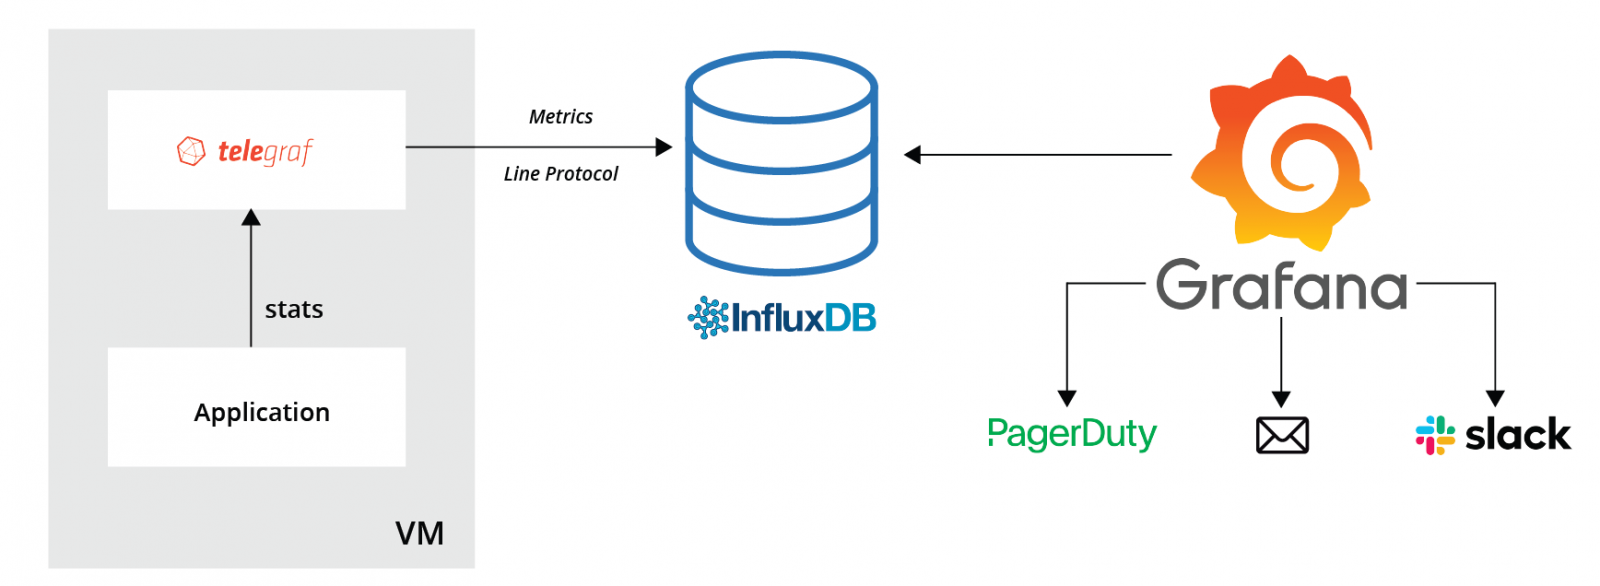

## PLG — Prometheus + Loki + Grafana

The **cloud-native, Kubernetes-native** observability stack. Most common in modern microservice environments.

```
┌──────────────────────────────────────────────────────────────────────┐
│                          PLG STACK                                   │
│                                                                      │
│  Microservices expose /metrics                                       │
│  ┌──────────┐  ┌──────────┐  ┌──────────┐                           │
│  │ Service A│  │ Service B│  │ Service C│                           │
│  │ :8080/   │  │ :8080/   │  │ :8080/   │                           │
│  │ metrics  │  │ metrics  │  │ metrics  │                           │
│  └────┬─────┘  └────┬─────┘  └────┬─────┘                           │
│       │  scrape (pull)  │         │                                  │
│  ┌────▼─────────────────▼─────────▼─────┐                           │
│  │            Prometheus                 │ ──── Alertmanager         │
│  │    (scrapes + stores metrics)         │      → PagerDuty          │
│  └────────────────┬──────────────────────┘      → Slack             │
│                   │ query (PromQL)               → Email             │
│  stdout logs      │                                                  │
│  ┌────────────────▼──────────────────────┐                           │
│  │  Promtail/Fluent Bit  →  Loki         │                           │
│  │  (tail logs)             (log store)  │                           │
│  └────────────────┬──────────────────────┘                           │
│                   │ query (LogQL)                                    │
│  ┌────────────────▼──────────────────────┐                           │
│  │              Grafana                  │                           │
│  │  (unified: metrics + logs in one UI)  │                           │
│  └───────────────────────────────────────┘                           │
└──────────────────────────────────────────────────────────────────────┘
```

| Role | Tool | Responsibility |
|------|------|----------------|
| Metrics collect + store | Prometheus | Pulls /metrics, stores TSDB, fires alerts |
| Log collect | Promtail / Fluent Bit | Tails container logs, ships to Loki |
| Log store | Loki | Label-indexed log storage |
| Visualize | Grafana | Unified metrics + logs dashboards |
| Alert route | Alertmanager | Routes to PagerDuty / Slack |

**When to use PLG:**
- Kubernetes / containerized microservices
- Open-source budget — no commercial tool costs
- You want metrics and logs in one Grafana UI

---
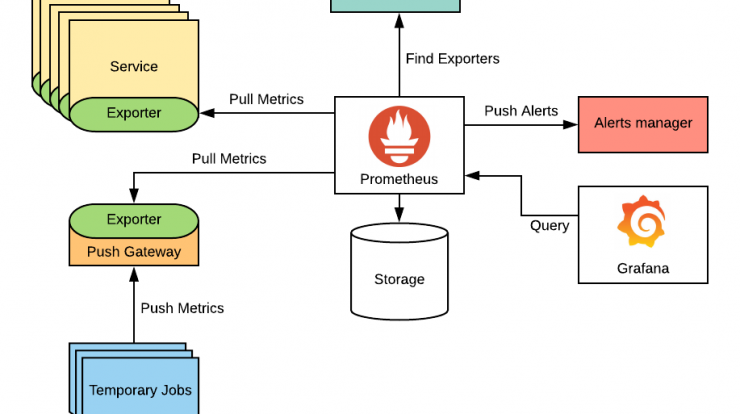

## ELK — Elasticsearch + Logstash + Kibana

The original **log analytics** stack. Built for powerful full-text search over large log volumes.

```
┌──────────────────────────────────────────────────────────────────────┐
│                          ELK STACK                                   │
│                                                                      │
│  ┌──────────┐  ┌──────────┐  ┌──────────┐                           │
│  │ Service A│  │ Service B│  │ Nginx    │                           │
│  │  logs    │  │  logs    │  │  logs    │                           │
│  └────┬─────┘  └────┬─────┘  └────┬─────┘                           │
│       └──────────────┼─────────────┘                                 │
│                      │  logs                                         │
│               ┌──────▼──────────────┐                                │
│               │      Logstash       │  parse / transform / enrich   │
│               │  (ETL pipeline)     │  grok, geo-IP, field mapping  │
│               └──────┬──────────────┘                                │
│                      │  structured docs                               │
│               ┌──────▼──────────────┐                                │
│               │   Elasticsearch     │  index + store                 │
│               │  (search engine)    │  full-text search, aggregations│
│               └──────┬──────────────┘                                │
│                      │                                               │
│               ┌──────▼──────────────┐                                │
│               │      Kibana         │  search UI, dashboards,        │
│               │  (UI + dashboards)  │  Discover, Lens, Alerts        │
│               └─────────────────────┘                                │
└──────────────────────────────────────────────────────────────────────┘
```

| Role | Tool | Responsibility |
|------|------|----------------|
| Transform | Logstash | Parse raw logs (grok), enrich, output to ES |
| Store + Search | Elasticsearch | Inverted index, full-text search, aggregations |
| Visualize | Kibana | Log explorer (Discover), dashboards, alerting |

**When to use ELK:**
- You need powerful full-text search across logs (regex, fuzzy, semantic)
- Security/compliance use cases (SIEM)
- Large-scale log analytics with complex transformations

**Tradeoff:** Resource-heavy and expensive to operate. Logstash is often replaced by Fluent Bit (→ EFK) for lower overhead.

---

## EFK — Elasticsearch + Fluentd + Kibana

ELK with **Logstash replaced by Fluentd/Fluent Bit** — lighter collection, same powerful search.

```
Services → Fluent Bit (lightweight, sidecar)
               ↓
           Fluentd (optional aggregator layer for routing/buffering)
               ↓
         Elasticsearch → Kibana
```

**Why EFK over ELK:**
- Fluent Bit uses ~1MB RAM vs Logstash's 300MB+ (JVM)
- Kubernetes-native — Fluent Bit runs as a DaemonSet, tails every pod's logs automatically
- Fluentd has 1000+ plugins for routing logs to multiple destinations

**When to use EFK:**
- Kubernetes environments (Fluent Bit is the standard k8s log shipper)
- You want ES search power but Logstash is too heavy

---

## OTel + Grafana Stack — Prometheus + Loki + Tempo + Grafana

The **vendor-neutral, full three-pillars** stack. Metrics + Logs + Traces, all in Grafana.

```
┌──────────────────────────────────────────────────────────────────────┐
│                    OTel + GRAFANA STACK                              │
│                                                                      │
│  Application (OTel SDK auto-instrumentation)                         │
│  ┌───────────────────────────────────────────┐                       │
│  │  Traces (spans) + Metrics + Logs          │                       │
│  └────────────────┬──────────────────────────┘                       │
│                   │ OTLP (gRPC / HTTP)                               │
│  ┌────────────────▼──────────────────────────┐                       │
│  │         OpenTelemetry Collector            │  batching,           │
│  │              (gateway)                    │  sampling,            │
│  └────┬──────────────┬──────────────┬────────┘  PII scrubbing        │
│       │              │              │                                 │
│  ┌────▼─────┐  ┌─────▼────┐  ┌─────▼────┐                           │
│  │Prometheus│  │   Loki   │  │  Tempo   │                           │
│  │(metrics) │  │  (logs)  │  │ (traces) │                           │
│  └────┬─────┘  └─────┬────┘  └─────┬────┘                           │
│       └──────────────┼──────────────┘                                │
│                      │ unified query                                  │
│               ┌──────▼───────────────┐                               │
│               │        Grafana        │                               │
│               │  Explore: click trace │                               │
│               │  → jump to logs       │                               │
│               │  → jump to metrics    │                               │
│               └──────────────────────┘                               │
└──────────────────────────────────────────────────────────────────────┘
```

| Role | Tool | Responsibility |
|------|------|----------------|
| Instrument | OTel SDK | Auto-instrument code, propagate context |
| Collect + route | OTel Collector | Batch, sample, scrub PII, fan-out to backends |
| Metrics | Prometheus | Store + query metrics |
| Logs | Loki | Store + query logs |
| Traces | Tempo | Store + look up traces by ID |
| Visualize | Grafana | Unified UI: correlate metrics ↔ logs ↔ traces |
| Alert | Alertmanager / Grafana Alerting | Route to PagerDuty / Slack |

**The killer feature:** In Grafana, click on a metric spike → see the correlated logs at that timestamp → click the trace_id in the log → open the trace in Tempo. Full investigation without switching tools.

**When to use:**
- You want full observability (all three pillars) without vendor lock-in
- Microservices on Kubernetes
- You have engineering capacity to run the stack

---

## Datadog — Full-Stack Commercial

The **SaaS alternative** to the OTel + Grafana stack. Same capabilities, higher cost, far less operational burden.

```
┌──────────────────────────────────────────────────────────────────────┐
│                       DATADOG STACK                                  │
│                                                                      │
│  Application                                                         │
│  ┌─────────────────────────────────────────┐                         │
│  │  Datadog APM SDK (auto-instrumentation) │                         │
│  └─────────────────┬───────────────────────┘                         │
│                    │ traces + metrics + logs                          │
│  ┌─────────────────▼───────────────────────┐                         │
│  │         Datadog Agent (host/container)  │                         │
│  │  - collects host metrics                │                         │
│  │  - tails logs                           │                         │
│  │  - receives APM traces                  │                         │
│  └─────────────────┬───────────────────────┘                         │
│                    │ HTTPS                                            │
│  ┌─────────────────▼───────────────────────┐                         │
│  │         Datadog SaaS Platform           │                         │
│  │  ┌──────────┐ ┌──────────┐ ┌─────────┐ │                         │
│  │  │ Metrics  │ │   Logs   │ │  APM    │ │                         │
│  │  │ (infra)  │ │ (search) │ │(traces) │ │                         │
│  │  └──────────┘ └──────────┘ └─────────┘ │                         │
│  │  ┌──────────────────────────────────┐   │                         │
│  │  │  Dashboards + Monitors + Alerts  │   │                         │
│  │  └──────────────────────────────────┘   │                         │
│  └───────────────────────┬─────────────────┘                         │
│                          │ alerts                                     │
│              ┌───────────▼──────────┐                                │
│              │  PagerDuty / Slack / │                                │
│              │  OpsGenie / Email    │                                │
│              └──────────────────────┘                                │
└──────────────────────────────────────────────────────────────────────┘
```

| Role | Tool | Responsibility |
|------|------|----------------|
| Everything | Datadog Agent | Single agent collects metrics, logs, traces |
| Store + analyze | Datadog SaaS | Managed storage, indexing, correlation |
| Visualize | Datadog Dashboards | Pre-built + custom dashboards |
| Alert | Datadog Monitors | Threshold, anomaly, forecast, composite alerts |
| On-call | PagerDuty / OpsGenie integration | Route critical alerts |

**When to use:**
- Team wants operational simplicity over cost savings
- Need to be productive fast (minutes to useful dashboards)
- Can afford $20–40/host/month

---

## Stack Selection Guide

```
┌──────────────────────────────────────────────────────────┐
│              WHICH STACK SHOULD I USE?                   │
│                                                          │
│  Budget tight + Kubernetes?                              │
│  └──► PLG (Prometheus + Loki + Grafana)                  │
│                                                          │
│  Infrastructure metrics + VMs (not k8s)?                 │
│  └──► TIG (Telegraf + InfluxDB + Grafana)                │
│                                                          │
│  Need powerful log search / security (SIEM)?             │
│  └──► EFK (Elasticsearch + Fluent Bit + Kibana)          │
│                                                          │
│  Want all 3 pillars + vendor neutrality?                 │
│  └──► OTel + Grafana Stack                               │
│                                                          │
│  Willing to pay for operational simplicity?              │
│  └──► Datadog / New Relic                                │
│                                                          │
│  Enterprise + AI-driven root cause?                      │
│  └──► Dynatrace                                          │
└──────────────────────────────────────────────────────────┘
```
